In [17]:

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from PIL import Image
from tqdm import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Устройство: {device}")

BASE_DIR = 'csv'

✅ Устройство: cpu


Train: 1500 изображений
Test: 300 изображений

Распределение классов в train:
label
0    500
1    500
2    500
Name: count, dtype: int64


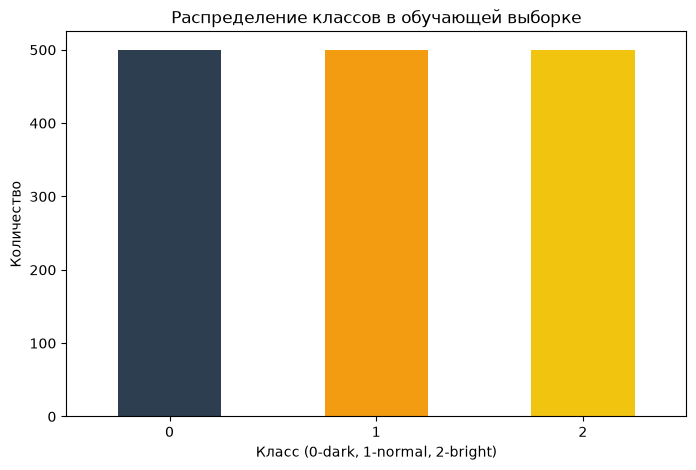

In [18]:
train_df = pd.read_csv(f'{BASE_DIR}/train.csv')
test_df = pd.read_csv(f'{BASE_DIR}/test.csv')


print(f"Train: {len(train_df)} изображений")
print(f"Test: {len(test_df)} изображений")

print("\nРаспределение классов в train:")
print(train_df['label'].value_counts().sort_index())

# Визуализация распределения
plt.figure(figsize=(8, 5))
train_df['label'].value_counts().sort_index().plot(kind='bar', color=['#2c3e50', '#f39c12', '#f1c40f'])
plt.title('Распределение классов в обучающей выборке')
plt.xlabel('Класс (0-dark, 1-normal, 2-bright)')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

In [19]:

class_names = {
    0: 'dark',
    1: 'normal',
    2: 'bright'
}

train_df['class_name'] = train_df['label'].map(class_names)
train_df['img_path'] = train_df.apply(
    lambda row: f"train/{class_names[row['label']]}/{row['id']}.png",
    axis=1
)

print("Примеры путей:")
print(train_df[['id', 'label', 'class_name', 'img_path']].head())

Примеры путей:
                                     id  label class_name  \
0  02137a86-0743-40e0-845b-6d22d1d5cc85      0       dark   
1  025d39a8-7859-4558-9bf9-bbdd475c6100      0       dark   
2  02a2a878-c5a4-490a-8061-6b2f4ac3b6d0      0       dark   
3  047f7996-9f0d-4a04-ae7f-24e246c407c7      0       dark   
4  052a9d62-a31f-4e4f-9a76-edac2d2ae95d      0       dark   

                                            img_path  
0  train/dark/02137a86-0743-40e0-845b-6d22d1d5cc8...  
1  train/dark/025d39a8-7859-4558-9bf9-bbdd475c610...  
2  train/dark/02a2a878-c5a4-490a-8061-6b2f4ac3b6d...  
3  train/dark/047f7996-9f0d-4a04-ae7f-24e246c407c...  
4  train/dark/052a9d62-a31f-4e4f-9a76-edac2d2ae95...  


In [20]:
IMG_SIZE = 224


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


valid_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Трансформации созданы")

✅ Трансформации созданы


In [21]:
train_data, valid_data = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['label'],
    random_state=42
)

print(f"Train: {len(train_data)} изображений")
print(f"Valid: {len(valid_data)} изображений")

print("\nРаспределение классов в train:")
print(train_data['label'].value_counts().sort_index())

print("\nРаспределение классов в valid:")
print(valid_data['label'].value_counts().sort_index())

Train: 1200 изображений
Valid: 300 изображений

Распределение классов в train:
label
0    400
1    400
2    400
Name: count, dtype: int64

Распределение классов в valid:
label
0    100
1    100
2    100
Name: count, dtype: int64


In [22]:
class LightDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        label = row['label']
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

print("✅ Класс LightDataset создан")

✅ Класс LightDataset создан


In [23]:
BATCH_SIZE = 32

train_dataset = LightDataset(train_data, transform=train_transform)
valid_dataset = LightDataset(valid_data, transform=valid_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Количество батчей в train: {len(train_loader)}")
print(f"Количество батчей в valid: {len(valid_loader)}")



Количество батчей в train: 38
Количество батчей в valid: 10


In [24]:
def create_model(num_classes=3):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    for param in model.parameters():
        param.requires_grad = False
    
    for param in model.layer4.parameters():
        param.requires_grad = True
    
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    
    return model

model = create_model().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print("✅ Модель создана")
print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")

✅ Модель создана
Количество параметров: 11,308,611


In [25]:
train_df.head(1)

,id,label,class_name,img_path
0,02137a86-0743-40e0-845b-6d22d1d5cc85,0,dark,train/dark/02137a86-0743-40e0-845b-6d22d1d5cc8...


In [26]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc='Обучение'):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), correct / total

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Валидация'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(loader), correct / total, all_preds, all_labels

print("✅ Функции обучения созданы")

✅ Функции обучения созданы


In [27]:
EPOCHS = 30
best_acc = 0
patience = 5
counter = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("="*50)
print("НАЧАЛО ОБУЧЕНИЯ")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nЭпоха {epoch+1}/{EPOCHS}")
    print("-" * 30)
    
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_preds, val_labels = validate(model, valid_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # ReduceLROnPlateau
    scheduler.step(val_loss)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Early Stopping
    if val_acc > best_acc:
        best_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"✅ Новая лучшая модель! Acc: {best_acc:.4f}")
    else:
        counter += 1
        if counter >= patience:
            print(f"⏹️ Early stopping на эпохе {epoch+1}")
            break

print(f"\n🏆 Лучшая точность на валидации: {best_acc:.4f}")

НАЧАЛО ОБУЧЕНИЯ

Эпоха 1/30
------------------------------


Валидация: 100%|██████████| 10/10 [00:12<00:00,  1.29s/it]


Train Loss: 1.1403, Train Acc: 0.4000
Val Loss: 1.1809, Val Acc: 0.4500
✅ Новая лучшая модель! Acc: 0.4500

Эпоха 2/30
------------------------------


Валидация: 100%|██████████| 10/10 [00:12<00:00,  1.21s/it]


Train Loss: 1.0094, Train Acc: 0.4833
Val Loss: 0.9970, Val Acc: 0.4900
✅ Новая лучшая модель! Acc: 0.4900

Эпоха 3/30
------------------------------


...

Train Loss: 0.1276, Train Acc: 0.9583
Val Loss: 1.9651, Val Acc: 0.5000

Эпоха 18/30
------------------------------


Валидация: 100%|██████████| 10/10 [00:12<00:00,  1.20s/it]


Train Loss: 0.1278, Train Acc: 0.9642
Val Loss: 2.1098, Val Acc: 0.4800

Эпоха 19/30
------------------------------


Валидация: 100%|██████████| 10/10 [00:20<00:00,  2.06s/it]

Train Loss: 0.0894, Train Acc: 0.9733
Val Loss: 2.1107, Val Acc: 0.4800
⏹️ Early stopping на эпохе 19

🏆 Лучшая точность на валидации: 0.5200


Валидация: 100%|██████████| 10/10 [00:12<00:00,  1.28s/it]



Финальная точность на валидации: 0.5200

Classification Report:
              precision    recall  f1-score   support

        dark       0.54      0.68      0.60       100
      normal       0.55      0.55      0.55       100
      bright       0.45      0.33      0.38       100

    accuracy                           0.52       300
   macro avg       0.51      0.52      0.51       300
weighted avg       0.51      0.52      0.51       300



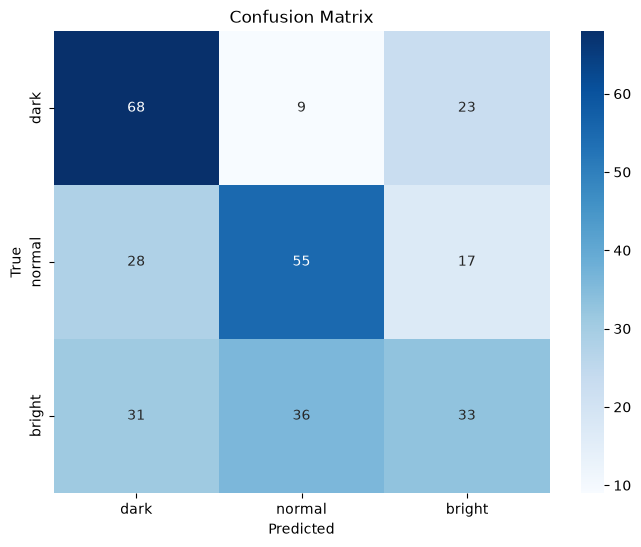

In [28]:

model.load_state_dict(torch.load('best_model.pth'))

_, final_acc, final_preds, final_labels = validate(model, valid_loader, criterion)
print(f"\nФинальная точность на валидации: {final_acc:.4f}")

print("\nClassification Report:")
print(classification_report(final_labels, final_preds, target_names=['dark', 'normal', 'bright']))

# Confusion Matrix
cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['dark', 'normal', 'bright'],
            yticklabels=['dark', 'normal', 'bright'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [29]:

def predict_with_tta(model, img_path, n_augmentations=5):
    model.eval()
    predictions = []
    
    tta_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    for _ in range(n_augmentations):
        img = Image.open(img_path).convert('RGB')
        img = tta_transforms(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(img)
            pred = torch.softmax(output, dim=1).cpu().numpy()
            predictions.append(pred)
    
    avg_pred = np.mean(predictions, axis=0)
    return np.argmax(avg_pred), avg_pred

print("✅ TTA функция создана")

✅ TTA функция создана


In [31]:

model.load_state_dict(torch.load('best_model.pth'))

predictions = []
probas = []

print("="*50)
print("ПРЕДСКАЗАНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*50)

for img_id in tqdm(test_df['id'], desc='Предсказание'):
    img_path = f"test/{img_id}.png"
    pred, prob = predict_with_tta(model, img_path, n_augmentations=5)
    predictions.append(pred)
    probas.append(prob)

print("✅ Все предсказания готовы")

ПРЕДСКАЗАНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ


Предсказание: 100%|██████████| 300/300 [5:05:25<00:00, 61.09s/it]     

✅ Все предсказания готовы


In [33]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'label': predictions
})

submission.to_csv('submission.csv', index=False)
print("\n✅ Сабмит сохранён в submission.csv")

print("\nПервые 10 строк сабмита:")
print(submission.head(10))

print(f"\nРаспределение предсказанных классов:")
print(submission['label'].value_counts().sort_index())


✅ Сабмит сохранён в submission.csv

Первые 10 строк сабмита:
                                     id  label
0  2c36c4a7-dccd-43a6-b7f3-67f2cecfb84b      0
1  4d7c9005-eb22-4ad2-b3b1-c187fa2ede50      0
2  4f5a98d9-485d-4eb6-9914-85777cfb67a9      0
3  9abb599e-6ede-43ee-b30f-4c74960664bd      0
4  3e4ecced-b8c5-4898-9ce2-9ae2c34a4eff      0
5  7ec17dfe-1980-4653-9a1d-7d967bdaba32      1
6  9007c5f2-2c66-42ae-9a26-92081ca38aba      0
7  8430c1f4-1e85-42e5-9cf3-1c1cc68f1f94      0
8  15f033e1-b448-477c-b6a5-8f77a79c9637      0
9  dbcc6918-6965-4607-8445-98302ca3db4f      0

Распределение предсказанных классов:
label
0    126
1     83
2     91
Name: count, dtype: int64
